
<div dir=ltr align=center>

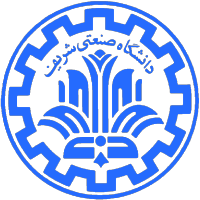

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Dimensionality Reduction: Principal Component Analysis<br>
<font color=696880 size=4>
    Prepared by Fatemeh Khojasteh <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [164]:
student_number = 'Narges Kari'
full_name = '402110821'

# Image Compression with PCA (From Scratch)

## Objective
 The goal of this assignment is to gain a deep understanding of **Principal Component Analysis (PCA)** by implementing it from scratch and applying it to image compression.

## Problem Statement
 Consider a grayscale image. We want to reduce its dimensionality by dividing the image into small "patches" and treating each patch as a data vector.

**Workflow:**
 1.  **Image Preparation:** Load the local image and convert it to grayscale.
 2.  **Patch Extraction:** Divide the image into small squares (e.g., $12 \times 12$). Each patch, when flattened, becomes a vector of dimension $144$.
 3.  **PCA Implementation:** Complete the `PCAFromScratch` class. You must calculate the covariance matrix, find eigenvalues/eigenvectors, and project data into a lower-dimensional space.
 4.  **Compression & Reconstruction:** Project the patches into a lower-dimensional space (e.g., 16 dimensions) and then reconstruct them back to 144 dimensions.
 5.  **Stitching:** Reassemble the reconstructed patches to form the final image.
 6.  **Visualization:** Visualize the top 16 Principal Components (Eigenfaces/Eigenpatches).


## Rules & Constraints
 1.  **No `sklearn`:** You are **NOT** allowed to use `sklearn.decomposition.PCA`. You must implement the logic using `numpy` (functions like `np.cov`, `np.linalg.eig`, `np.linalg.svd` are allowed).
 2.  **Allowed Libraries:** `numpy`, `matplotlib`, `cv2` (or `PIL`).
 3.  **Flexibility:** Your code should handle images that may not be perfectly divisible by the patch size (you should implement cropping logic).


In [165]:
# Import needed libraries

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

## Part 1: PCA Class Implementation

 In this section, you must implement the PCA algorithm from scratch.

 **Implementation Steps for `fit`:**
 1. Calculate the mean of the columns.
 2. Center the data ($X - \text{mean}$).
 3. Compute the Covariance Matrix.
 4. Compute Eigenvalues and Eigenvectors.
 5. Sort Eigenvectors by Eigenvalues in descending order.
 6. Store the top `n_components` eigenvectors.

In [166]:
class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance = None

    def fit(self, X):
        self.mean = X.mean(axis=0)
        C = X - self.mean
        M = np.cov(C, rowvar=False)
        vals, vecs = np.linalg.eig(M)
        idx = np.argsort(vals)[::-1]
        vals = vals[idx]
        vecs = vecs[:, idx]
        self.components = vecs[:, :self.n_components]
        self.explained_variance = vals[:self.n_components]

    def transform(self, X):
        C = X - self.mean
        return C @ self.components

    def inverse_transform(self, Z):
        return Z @ self.components.T + self.mean


## Part 2: Patch Extraction Logic

 Implement functions to convert an image into a matrix of patches and vice versa.

 *Hint: It is easier to crop the image first so that its dimensions are divisible by the patch size.*


In [167]:
def get_valid_image_dims(img, pz):
    h, w = img.shape
    ph, pw = pz
    nh = h - (h % ph)
    nw = w - (w % pw)
    return img[:nh, :nw]


def image_to_patches(img, pz=(12, 12)):
    cim = get_valid_image_dims(img, pz)
    ph, pw = pz
    hh, ww = cim.shape
    nh = hh // ph
    nw = ww // pw
    X = cim.reshape(nh, ph, nw, pw).transpose(0, 2, 1, 3).reshape(nh*nw, ph*pw)

    return X, (hh, ww)


def patches_to_image(pchs, oshp, pz=(12, 12)):
    ph, pw = pz
    hh, ww = oshp
    nh = hh // ph
    nw = ww // pw
    return pchs.reshape(nh, nw, ph, pw).transpose(0, 2, 1, 3).reshape(hh, ww)


## Part 3: Execution Pipeline

 Write the code to execute the PCA pipeline.

 1. Load the image.
 2. Convert image to patches.
 3. Run PCA.
 4. Reconstruct image.
 5. Calculate error.

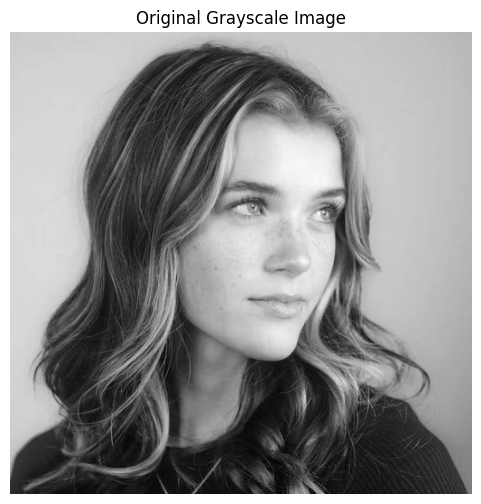

In [168]:
# --- 1. Load Image ---
# Ensure 'image.jpg' is in the same directory
IMAGE_PATH = 'image.jpg'

if not os.path.exists(IMAGE_PATH):
    print(f"Warning: {IMAGE_PATH} not found. Generating random noise for testing.")
    gray = np.random.rand(512, 512) * 255
else:
    img = Image.open(IMAGE_PATH).convert('L') # Convert to Grayscale
    gray = np.array(img)

plt.figure(figsize=(6, 6))
plt.title("Original Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

In [169]:
# --- 2. Prepare Data ---
PATCH_SIZE = (12, 12)

pc, vs = image_to_patches(gray, PATCH_SIZE)

print("Original Image Shape:", gray.shape)
print("Valid Image Shape (Cropped):", vs)
print("Patches Matrix Shape:", pc.shape)


Original Image Shape: (512, 512)
Valid Image Shape (Cropped): (504, 504)
Patches Matrix Shape: (1764, 144)


In [170]:
# --- 3. Train PCA ---
N_COMPONENTS = 16

pca = PCAFromScratch(N_COMPONENTS)

pca.fit(pc)

all_vals = np.linalg.eigvals(np.cov(pc - pc.mean(0), rowvar=False)).real
ratio = pca.explained_variance.sum().real / all_vals.sum().real
print(f"Explained Variance Ratio (Top {N_COMPONENTS}): {ratio * 100:.2f}%")

Explained Variance Ratio (Top 16): 99.09%


In [171]:
# --- 4. Compress & Reconstruct ---

Z = pca.transform(pc)

R = pca.inverse_transform(Z)

print("Compressed Shape:", Z.shape)
print("Reconstructed Patches Shape:", R.shape)


Compressed Shape: (1764, 16)
Reconstructed Patches Shape: (1764, 144)


In [172]:
# --- 5. Reassemble Image ---

rec = patches_to_image(R, vs, PATCH_SIZE)

cropped_original = get_valid_image_dims(gray, PATCH_SIZE).astype(float)
cropped_reconstructed = rec.astype(float)

mse = np.mean((cropped_original - cropped_reconstructed) ** 2)
print(f"Reconstruction MSE: {mse:.2f}")

Reconstruction MSE: 25.36


## Part 4: Visualization

 Visualize the results and the learned features.


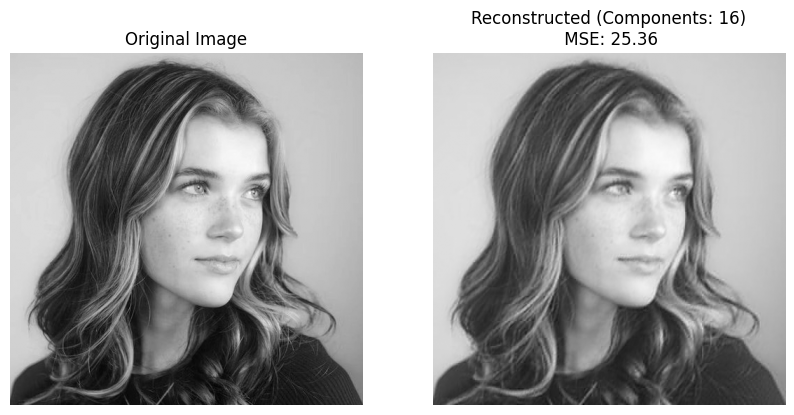

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(get_valid_image_dims(gray, PATCH_SIZE), cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Reconstructed Image
plt.subplot(1, 2, 2)
plt.imshow(rec, cmap='gray')
plt.title(f"Reconstructed (Components: {N_COMPONENTS})\n MSE: {mse:.2f}")
plt.axis('off')

plt.show()


## 1. Quality Comparison (Reconstruction Quality)

In the image above, you can see the original image next to the reconstructed one.

* **Interpretation:** The image on the right has been reconstructed using only **16 components**. Even though the data dimensions have been reduced by 9 times (from 144 features per patch to 16 features), the image is still easily recognizable.
* **Quality Loss:** If you look closely, the reconstructed image appears slightly "blurry," and high-frequency details (such as very fine textures on the hat or hair) have been removed. This is the price we pay for compression.
* **MSE:** The MSE (Mean Squared Error) value indicates the average squared error between the original and reconstructed pixels.


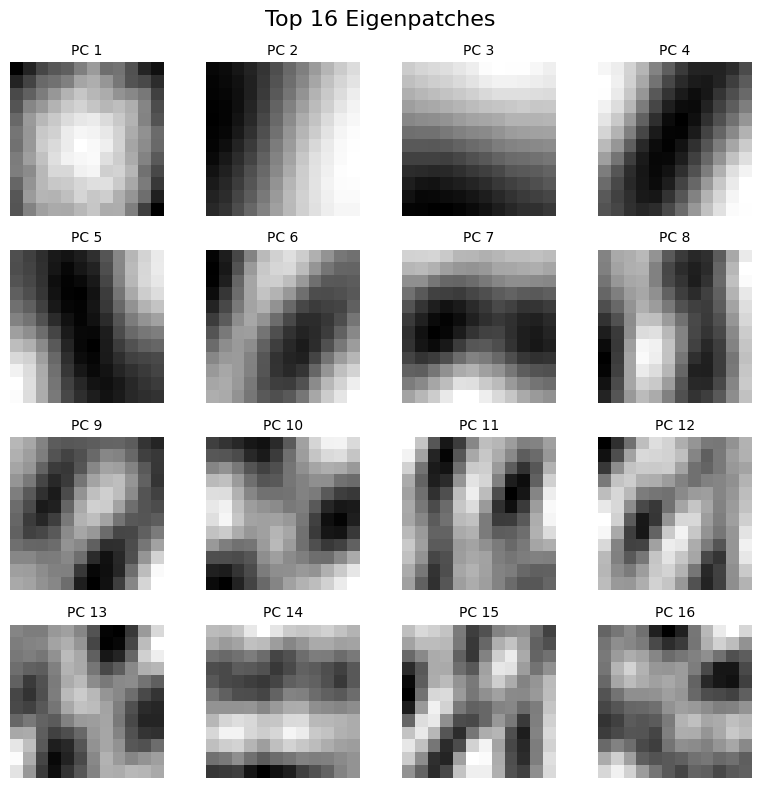

In [176]:
plt.figure(figsize=(8, 8))

for i in range(N_COMPONENTS):
    plt.subplot(4, 4, i + 1)
    eigenpatch_vector = pca.components[:, i]
    if np.mean(eigenpatch_vector) < 0:
        eigenpatch_vector = -eigenpatch_vector
    eigenpatch = eigenpatch_vector.reshape(PATCH_SIZE)
    ep_min, ep_max = eigenpatch.min(), eigenpatch.max()
    if ep_max > ep_min:
        eigenpatch_norm = (eigenpatch - ep_min) / (ep_max - ep_min)
    else:
        eigenpatch_norm = np.zeros_like(eigenpatch)

    plt.imshow(eigenpatch_norm, cmap='gray')
    plt.axis('off')
    plt.title(f"PC {i+1}", fontsize=10)

plt.suptitle("Top 16 Eigenpatches", fontsize=16)
plt.tight_layout()
plt.show()

In the image above, you can see the top 16 eigenvectors, which have been reshaped to dimensions of $12 \times 12$.

* **What are these?** These small squares are actually the "building blocks" of the image. The PCA algorithm has extracted these patterns from the Lenna image. Each patch in the final image is a linear combination of these 16 shapes.
* **Pattern Analysis:**
    * **Initial components (like PC1 and PC2):** Typically represent overall lighting changes and simple gradients (low frequency).
    * **Middle components:** Start to display directions (horizontal, vertical, or diagonal edges).
    * **Final components:** Model more complex details and fine textures (high frequency).
* **Why are they checkerboard-like?** These patterns are orthogonal and aim to cover the maximum variance present in the data.
